# Intro

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

%cd /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/playground-uc3/master-thesis/

/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/playground-uc3/master-thesis


In [30]:
TEST_RESULTS_PATH = 'thesis-figures/extended_cbm/results/2_test_metrics_aab_soft-bce.parquet'
VAL_RESULTS_PATH_RAW = 'thesis-figures/extended_cbm/results/1_extended_cbm_results.parquet'

In [31]:
def create_summary_table(df: pd.DataFrame, filter_tag:list[str], reference_measure:str):
    """Erstellt eine Tabelle mit den Bestwerten pro Run."""
    print("\nErstelle Summary Tabelle (Max-Werte)...")

    # filter df for each column where df[column] is true
    for tag in filter_tag:
        col = f"tag_{tag}"
        if col not in df.columns:
            raise ValueError(f"Tag-Spalte {col} existiert nicht im DataFrame.")
        df = df[df[col] == True]

    if df.empty:
        print("DataFrame nach Tag-Filter leer.")
        return df

    # Sicherstellen, dass innerhalb jedes Runs nach step sortiert ist
    df = df.sort_values(["run_id", "_step"]).copy()

    # Epoch als laufende Evaluation pro run_id (startet bei 0)
    df["epoch"] = df.groupby("run_id").cumcount()

    # Bestes F1-Concept pro Run auswählen
    best_per_run = (
        df.loc[df.groupby("run_id")[reference_measure].idxmax()]
        .reset_index(drop=True)
    )
    
    return best_per_run

In [32]:
# test_results = pd.read_parquet(TEST_RESULTS_PATH)
val_results_raw = pd.read_parquet(VAL_RESULTS_PATH_RAW)

val_results_soft = create_summary_table(val_results_raw, filter_tag=["aab-soft-bce"], reference_measure=r'$F_1$ Concept')
val_baseline = create_summary_table(val_results_raw, filter_tag=["aab-con-maskreg-intro"], reference_measure=r'$F_1$ Concept')
val_baseline = val_baseline[val_baseline['Concept Module']=='Top-K AvgPool']


Erstelle Summary Tabelle (Max-Werte)...

Erstelle Summary Tabelle (Max-Werte)...


In [33]:
val_results_soft['run_id'].nunique()

4

In [34]:
val_results_soft.head()

,_step,Recall-Concept,Precision-Concept,Total Loss,IoU-Mean,Foreground-Dice,$F_1$ Concept,Dice,Accuracy-Concept,Runtime (s),...,unified_model,Dataset,tag_Final,tag_aab-seg-benchmark,Loss Concepts,tag_aab-con,tag_aab-con-maskreg-intro,tag_aab-soft-bce,tag_aab-aff,epoch
0,1198,0.722896,0.479520,0.814543,0.599707,0.285679,0.565589,0.616629,0.765323,7582.620758,...,None,CUB_112,True,None,0.811127,None,None,True,None,15
1,1798,0.496460,0.588334,0.400675,0.701191,0.205835,0.527032,0.713753,0.824305,11455.985854,...,None,CUB_112,True,None,0.399110,None,None,True,None,23
2,599,0.712179,0.462123,0.843859,0.507398,0.303050,0.547538,0.525250,0.691144,3909.485713,...,None,CUB_112,True,None,0.837639,None,None,True,None,7
3,599,0.677818,0.470098,0.890584,0.532939,0.301868,0.542475,0.550458,0.702913,4412.549308,...,None,CUB_112,True,None,0.885309,None,None,True,None,7


In [35]:
val_results_soft.columns

Index(['_step', 'Recall-Concept', 'Precision-Concept', 'Total Loss',
       'IoU-Mean', 'Foreground-Dice', '$F_1$ Concept', 'Dice',
       'Accuracy-Concept', 'Runtime (s)', 'normalized_epoch', 'run_id',
       'Concept Module', 'Segmentation Module', 'concept_criterion',
       'use_soft_labels', 'unified_model', 'Dataset', 'tag_Final',
       'tag_aab-seg-benchmark', 'Loss Concepts', 'tag_aab-con',
       'tag_aab-con-maskreg-intro', 'tag_aab-soft-bce', 'tag_aab-aff',
       'epoch'],
      dtype='object')

In [36]:
val_results_soft_pretty = val_results_soft[
    ['Segmentation Module', 'Concept Module', 
     'Recall-Concept', 'Precision-Concept', 
     'IoU-Mean', 'Foreground-Dice', 
     '$F_1$ Concept', 'Dice',
    'Accuracy-Concept', 'run_id', 
       ]]

In [37]:
l = val_results_soft_pretty.to_latex()
print(l)

\begin{tabular}{lllrrrrrrrl}
\toprule
 & Segmentation Module & Concept Module & Recall-Concept & Precision-Concept & IoU-Mean & Foreground-Dice & $F_1$ Concept & Dice & Accuracy-Concept & run_id \\
\midrule
0 & Upscaled MultiLayer & Top-K AvgPool & 0.722896 & 0.479520 & 0.599707 & 0.285679 & 0.565589 & 0.616629 & 0.765323 & 17m6p70g \\
1 & Upscaled MultiLayer & Top-K AvgPool & 0.496460 & 0.588334 & 0.701191 & 0.205835 & 0.527032 & 0.713753 & 0.824305 & qatqo9db \\
2 & Upscaled MultiLayer & Top-K AvgPool & 0.712179 & 0.462123 & 0.507398 & 0.303050 & 0.547538 & 0.525250 & 0.691144 & quos7n74 \\
3 & Upscaled MultiLayer & Top-K AvgPool & 0.677818 & 0.470098 & 0.532939 & 0.301868 & 0.542475 & 0.550458 & 0.702913 & sltpp8ev \\
\bottomrule
\end{tabular}



In [4]:
import pandas as pd
import numpy as np

TEST_RESULTS_PATH_SOFTBCE = 'thesis-figures/extended_cbm/results/2_test_metrics_aab-soft-bce.parquet'

test_results = pd.read_parquet(TEST_RESULTS_PATH_SOFTBCE)
print(test_results[["Recall Concepts", "Precision Concepts", "Mean IoU", "Foreground Dice", "Concept Activations $F_1$-Score", "Mean Dice", "Concept Accuracy", "run_id"]].to_latex())

\begin{tabular}{lrrrrrrrl}
\toprule
 & Recall Concepts & Precision Concepts & Mean IoU & Foreground Dice & Concept Activations $F_1$-Score & Mean Dice & Concept Accuracy & run_id \\
\midrule
0 & 0.726707 & 0.484840 & 0.602115 & 0.286927 & 0.572716 & 0.619046 & 0.770184 & 17m6p70g \\
0 & 0.507522 & 0.595302 & 0.703031 & 0.209296 & 0.536414 & 0.715749 & 0.825921 & qatqo9db \\
0 & 0.816679 & 0.422491 & 0.507651 & 0.303601 & 0.540673 & 0.525556 & 0.705810 & quos7n74 \\
0 & 0.786436 & 0.431676 & 0.533386 & 0.301802 & 0.538530 & 0.550880 & 0.723595 & sltpp8ev \\
\bottomrule
\end{tabular}



# Image Examples

In [10]:
import torch
from tqdm import tqdm

from architecture.extended_cbm import ExtendedCBMOutput, init_from_checkpoint
from cbm_datasets import Batch, get_dataloader, get_datasets


In [11]:
train_dataset_cub, val_dataset_cub, test_dataset_cub, _, _, _ = get_datasets(dataset_name='CUB_112', 
                                                        root_dir='/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/datasets', 
                                                        img_size=256, 
                                                        use_soft_labels=False, concept_masks_scale='small',
                                                        attr_level='image')

train_loader_cub, val_loader_cub, test_loader_cub = get_dataloader(batch_size=4, num_workers=6, 
                                                       train_dataset=train_dataset_cub, val_dataset=val_dataset_cub, 
                                                       test_dataset=test_dataset_cub)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
iter_obj_cub = iter(val_loader_cub)
batch_cub: Batch = next(iter_obj_cub).to(device)

In [38]:
def load_and_predict(run_ids:list[str], epochs:list[int], datasets:list[str], batch:Batch,):

    predictions: list[ExtendedCBMOutput] = [] 
    for run_id, epoch, dataset in tqdm(zip(run_ids, epochs, datasets)):
    
        model = init_from_checkpoint(run_id=run_id, epoch=epoch, dataset=dataset.lower(), device=device)

        pred: ExtendedCBMOutput = model(batch.images)
        predictions.append(pred)

    return predictions

In [39]:
def plot_concept_masks_paper(predictions, gt_vector, concept_names, concept_splitter, images, batch_idx=0, alpha=0.3, cmap='magma'):
    """
    Erstellt einen strukturierten Plot für das Paper:
    - Gruppiert nach Körperteilen.
    - Zeigt Masken-Predictions.
    - Markiert Ground Truth (GT) Aktivierung durch Titel-Farbe (Grün = Aktiv, Rot = Inaktiv).
    """
    # Gruppierung der Konzepte (wir suchen nach dem Präfix vor dem Bindestrich)
    categories = {}
    for i, name in enumerate(concept_names):
        cat = name.split(concept_splitter)[0]
        if cat not in categories:
            categories[cat] = []
        categories[cat].append((i, name))

    num_categories = len(categories)

    image = images[batch_idx].permute(1,2,0).cpu().numpy()
    
    # Bestimme die maximale Anzahl an Konzepten pro Kategorie für die Spaltenanzahl
    max_cols = max(len(v) for v in categories.values())

    fig, axes = plt.subplots(num_categories, max_cols, 
                             figsize=(max_cols * 2.5, num_categories * 3))
    
    all_logits = predictions.segmentation_module.mask_logits[batch_idx].detach().cpu()

    for row_idx, (cat_name, items) in enumerate(categories.items()):
        for col_idx in range(max_cols):
            ax = axes[row_idx, col_idx]
            
            if col_idx < len(items):
                concept_idx, name = items[col_idx]
                
                # Maske berechnen
                mask = all_logits[concept_idx].sigmoid().numpy()
                is_active_gt = gt_vector[batch_idx, concept_idx] == 1
                
                # Plotting
                ax.imshow(image)  # zuerst das RGB-Bild (ohne cmap!)
                ax.imshow(mask, cmap=cmap, alpha=alpha, vmin=0, vmax=1)
                
                # Titel Styling: Grün wenn GT aktiv, sonst Grau/Rot
                color = 'green' if is_active_gt else 'black'
                weight = 'bold' if is_active_gt else 'normal'
                label = f"{name}\n(GT: {'Active' if is_active_gt else 'Off'})"
                
                ax.set_title(label, fontsize=10, color=color, fontweight=weight)
                
                # Optional: Rahmenfarbe passend zur GT
                for spine in ax.spines.values():
                    spine.set_edgecolor(color)
                    spine.set_linewidth(2 if is_active_gt else 0.5)
            else:
                # Leere Subplots ausblenden
                ax.axis('off')
            
            ax.set_xticks([])
            ax.set_yticks([])

        # Zeilenbeschriftung links
        axes[row_idx, 0].set_ylabel(cat_name.upper(), fontsize=14, fontweight='bold')

    plt.tight_layout()
    # Speichern als PDF für beste Qualität im Paper
    plt.savefig("concept_ablation_visual_fb_all-concepts.pdf", bbox_inches='tight', dpi=300)
    plt.show()

In [ ]:
def plot_single_concept_multi_model_paper(
    predictions_list,          # Liste von Model-Predictions
    model_names,               # Liste der Modellnamen (gleiche Reihenfolge)
    concept_id,                # Zu visualisierendes Konzept
    concept_names,
    gt_vector,
    images,
    batch_idx=0,
    alpha=0.35,
    cmap="magma",
    save_path=None
):
    """
    Paper-ready Plot:
    - Eine Reihe
    - Links: Originalbild
    - Danach: Predictions mehrerer Modelle
    - GT-Aktivierung wird farblich markiert
    """

    #denomalize images
    mean = torch.tensor([0.485, 0.456, 0.406], device=images.device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=images.device).view(1, 3, 1, 1)
    images = images * std + mean

    assert len(predictions_list) == len(model_names)

    image = images[batch_idx].permute(1, 2, 0).cpu().numpy()
    concept_name = concept_names[concept_id]
    is_active_gt = gt_vector[batch_idx, concept_id] == 1

    num_models = len(predictions_list)
    total_cols = num_models + 1  # +1 für Originalbild

    fig, axes = plt.subplots(
        1,
        total_cols,
        figsize=(total_cols * 3.2, 3.5)
    )

    # -----------------------
    # Originalbild
    # -----------------------
    axes[0].imshow(image)
    axes[0].set_title("Input Image", fontsize=11)
    axes[0].axis("off")

    # -----------------------
    # Modelle
    # -----------------------
    for i, (predictions, model_name) in enumerate(zip(predictions_list, model_names)):
        ax = axes[i + 1]

        logits = predictions.segmentation_module.mask_logits[batch_idx]
        mask = logits[concept_id].sigmoid().detach().cpu().numpy()

        ax.imshow(image)
        ax.imshow(mask, cmap=cmap, alpha=alpha, vmin=0, vmax=1)

        # Titel-Formatierung
        color = "green" if is_active_gt else "black"
        weight = "bold" if is_active_gt else "normal"

        ax.set_title(
            model_name,
            fontsize=10,
            color=color,
            fontweight=weight
        )

        # Rahmenfarbe
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2 if is_active_gt else 0.8)

        ax.set_xticks([])
        ax.set_yticks([])

    # -----------------------
    # Gesamttitel
    # -----------------------
    fig.suptitle(
        f"Concept: {concept_name} | GT: {'Active' if is_active_gt else 'Inactive'}",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5877123].


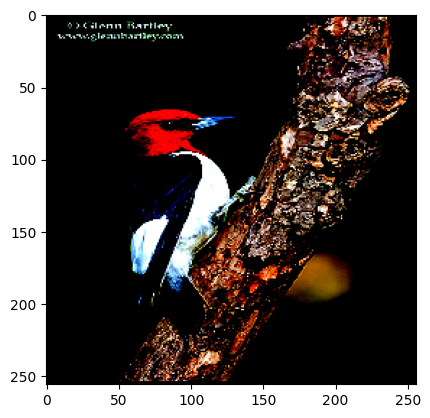

In [41]:
plt.imshow(batch_cub.images.detach().cpu()[1].numpy().transpose(1,2,0))

In [53]:
val_results = pd.concat([val_baseline, val_results_soft])
val_results.head()

,_step,Recall-Concept,Precision-Concept,Total Loss,IoU-Mean,Foreground-Dice,$F_1$ Concept,Dice,Accuracy-Concept,Runtime (s),...,unified_model,Dataset,tag_Final,tag_aab-seg-benchmark,Loss Concepts,tag_aab-con,tag_aab-con-maskreg-intro,tag_aab-soft-bce,tag_aab-aff,epoch
2,1498,0.496316,0.591103,0.389537,0.710313,0.213220,0.528256,0.723023,0.825498,11787.990558,...,None,CUB_112,True,None,0.389190,None,True,None,None,19
0,1198,0.722896,0.479520,0.814543,0.599707,0.285679,0.565589,0.616629,0.765323,7582.620758,...,None,CUB_112,True,None,0.811127,None,None,True,None,15
1,1798,0.496460,0.588334,0.400675,0.701191,0.205835,0.527032,0.713753,0.824305,11455.985854,...,None,CUB_112,True,None,0.399110,None,None,True,None,23
2,599,0.712179,0.462123,0.843859,0.507398,0.303050,0.547538,0.525250,0.691144,3909.485713,...,None,CUB_112,True,None,0.837639,None,None,True,None,7
3,599,0.677818,0.470098,0.890584,0.532939,0.301868,0.542475,0.550458,0.702913,4412.549308,...,None,CUB_112,True,None,0.885309,None,None,True,None,7


In [70]:
header = ['Baseline \n ($\lambda_\mathrm{maskreg}=0.01$ )', 'ICW hard', 'normal hard', 'ICW soft', 'normal soft']

In [75]:
predictions_cub = load_and_predict(
    run_ids=val_results['run_id'].to_list(), 
    epochs=val_results['epoch'].astype(int).to_list(), 
    datasets=val_results['Dataset'].to_list(), 
    batch=batch_cub)

0it [00:00, ?it/s]Using cache found in /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache/hub/wimmerth_anyup_main
1it [00:16, 16.54s/it]Using cache found in /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache/hub/wimmerth_anyup_main
2it [00:18,  7.88s/it]Using cache found in /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache/hub/wimmerth_anyup_main
3it [00:20,  5.11s/it]Using cache found in /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache/hub/wimmerth_anyup_main
4it [00:21,  3.78s/it]Using cache found in /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/.cache/hub/wimmerth_anyup_main
5it [00:23,  4.71s/it]


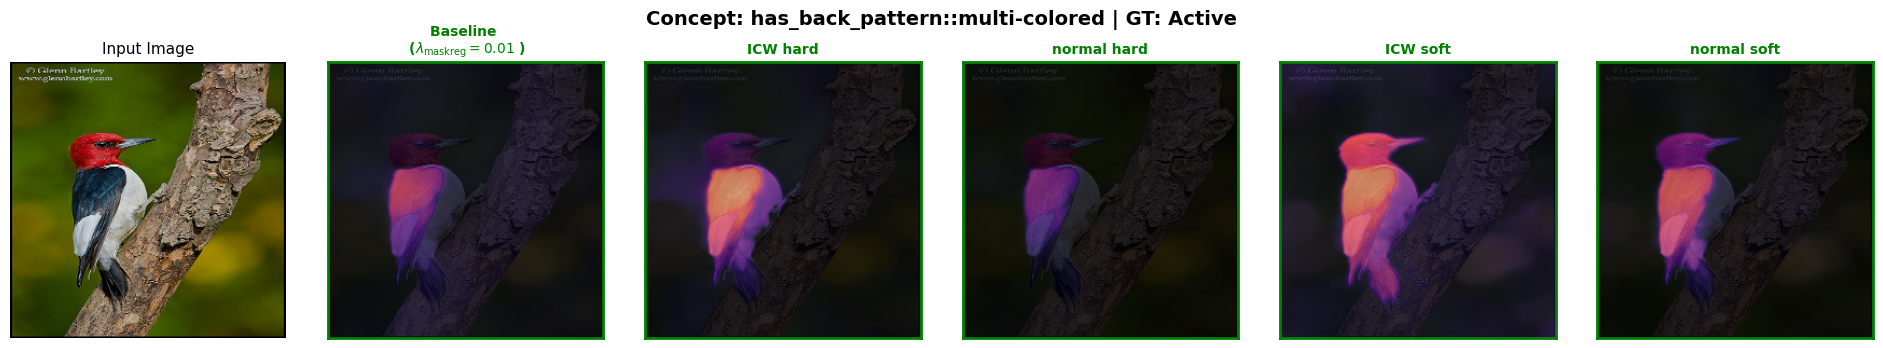

In [94]:
plot_single_concept_multi_model_paper(
    predictions_list=predictions_cub,
    model_names=header,
    concept_id=85,  # Beispiel: Erstes Konzept
    concept_names=val_dataset_cub.concepts.to_list(),
    gt_vector=batch_cub.concepts,
    images=batch_cub.images,
    save_path="thesis-figures/extended_cbm/outputs/segmodule_comparison_cub_1.pdf",
    batch_idx=1,
    alpha=0.8
)

In [62]:
for prediction in predictions_cub:
    prediction.segmentation_module.mask_logits = prediction.segmentation_module.mask_logits.sigmoid() > 0.5

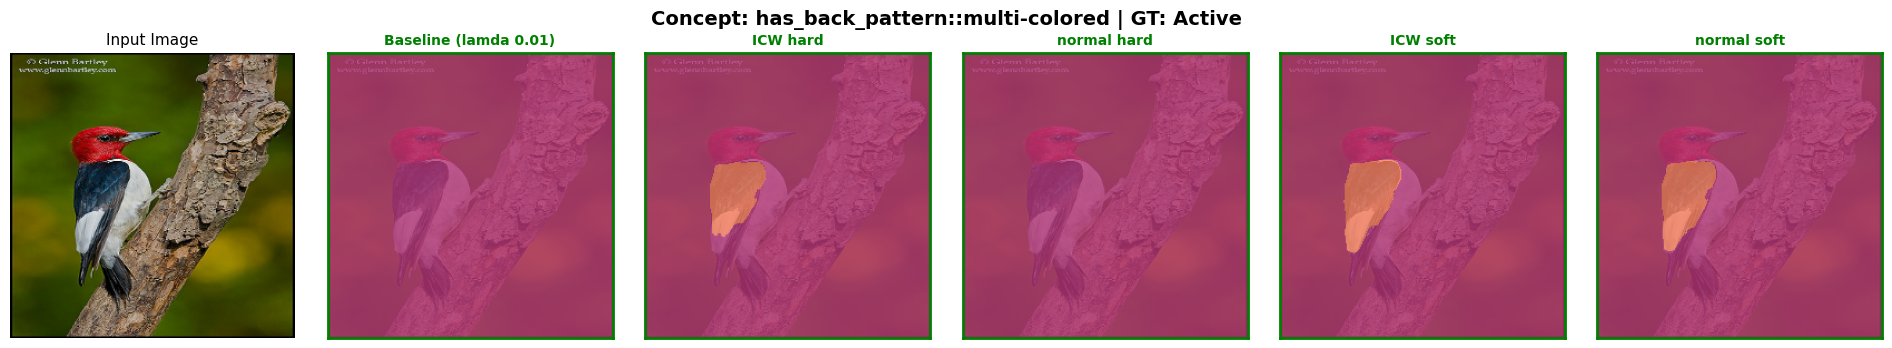

In [63]:
plot_single_concept_multi_model_paper(
    predictions_list=predictions_cub,
    model_names=header,
    concept_id=85,  # Beispiel: Erstes Konzept
    concept_names=val_dataset_cub.concepts.to_list(),
    gt_vector=batch_cub.concepts,
    images=batch_cub.images,
    save_path="thesis-figures/extended_cbm/outputs/segmodule_comparison_cub_1.pdf",
    batch_idx=1,
    alpha=0.8
)

In [171]:
from typing import Any

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import torch


def plot_concept_masks_paper_layout(
    predictions_list: list[Any],
    concept_id: int,
    concept_names: list[str],
    gt_vector: torch.Tensor,
    images: torch.Tensor,
    figsize: tuple[int, int] = (12, 6),
    batch_idx: int = 0,
    alpha: float = 0.7,
    cmap: str = "magma",
    save:  bool = False,
) -> plt.Figure:
    
    # --- Daten Vorbereitung ---
    images = images.detach()
    gt_vector = gt_vector.detach()

    # De-Normalisierung (ImageNet)
    mean = torch.tensor([0.485, 0.456, 0.406], device=images.device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=images.device).view(1, 3, 1, 1)
    images = (images * std + mean).clamp(0, 1)
    image = images[batch_idx].permute(1, 2, 0).cpu().numpy()
    
    concept_name = concept_names[concept_id]
    baseline, nw_ls0, nw_ls1, w_ls0, w_ls1 = predictions_list

    # --- Paper Style Konfiguration ---
    rc = {
        "font.family": "serif",
        # "font.serif": ["Times New Roman", "DejaVu Serif"],
        "font.size": 12,
        "axes.titlesize": 11,
        "axes.labelsize": 12,
    }

    with plt.rc_context(rc):
        fig = plt.figure(figsize=figsize)
        
        # GridSpec: Wir nutzen 3 Spalten mit unterschiedlichen Breiten-Verhältnissen,
        # um den Platz für den Text zwischen Spalte 1 und 2 zu schaffen.
        # Spalte 0 (Input), dann Platz, dann Spalte 1 & 2 (Masken)
        gs = gridspec.GridSpec(2, 3, figure=fig, wspace=0.1, hspace=0.2)
        
        # Achsen erstellen
        ax_input = fig.add_subplot(gs[0, 0])
        ax_nw_ls0 = fig.add_subplot(gs[0, 1])
        ax_nw_ls1 = fig.add_subplot(gs[0, 2])
        
        ax_base  = fig.add_subplot(gs[1, 0])
        ax_w_ls0  = fig.add_subplot(gs[1, 1])
        ax_w_ls1  = fig.add_subplot(gs[1, 2])

        all_axes = [ax_input, ax_nw_ls0, ax_nw_ls1, ax_base, ax_w_ls0, ax_w_ls1]

        def draw_mask(ax, pred, title=None):
            mask = pred.segmentation_module.mask_logits.detach()[batch_idx, concept_id].sigmoid().cpu().numpy()
            ax.imshow(image)
            ax.imshow(mask, cmap=cmap, alpha=alpha, vmin=0, vmax=1)
            if title: ax.set_title(title, pad=10, fontweight="bold")

        # --- Plots füllen ---
        # Reihe 1
        ax_input.imshow(image)
        ax_input.set_title("Input Image", pad=10)
        draw_mask(ax_nw_ls0, nw_ls0, title="Label Smoothing: No")
        draw_mask(ax_nw_ls1, nw_ls1, title="Label Smoothing: Yes")

        # Reihe 2
        draw_mask(ax_base, baseline, title="Baseline")
        draw_mask(ax_w_ls0, w_ls0)
        draw_mask(ax_w_ls1, w_ls1)

        # Aufräumen: Ticks weg
        for ax in all_axes:
            ax.set_xticks([])
            ax.set_yticks([])

        # --- Text ZWISCHEN die Spalten setzen ---
        # Wir holen uns die Positionen der Subplots im Figure-Space
        plt.draw() # Erzwingt das Layout-Rendering, um Positionen zu berechnen
        
        pos_input = ax_input.get_position()
        pos_nw = ax_nw_ls0.get_position()
        pos_base = ax_base.get_position()
        pos_w = ax_w_ls0.get_position()

        # Berechne die Mitte zwischen rechter Kante Spalte 1 und linker Kante Spalte 2
        mid_x = (pos_input.x1 + pos_nw.x0) / 2 - 0.01

        # Text für obere Reihe
        fig.text(mid_x, (pos_input.y0 + pos_input.y1)/2, "\n\nNo\nWeighting", 
                 rotation=90, va='center', ha='center', fontweight='bold', fontsize=11)
        
        # Text für untere Reihe
        fig.text(mid_x, (pos_base.y0 + pos_base.y1)/2, "\n\nWith\nWeighting", 
                 rotation=90, va='center', ha='center', fontweight='bold', fontsize=11)

        # --- Abstände zwischen Spalte 2 und 3 minimieren ---
        # Wir rücken ax_nw_ls1 und ax_w_ls1 näher an ihre linken Nachbarn
        # (Das machen wir über eine kleine händische Korrektur der Position)
        shift = 0.04 
        for ax in [ax_nw_ls1, ax_w_ls1]:
            pos = ax.get_position()
            ax.set_position([pos.x0 - shift, pos.y0, pos.width, pos.height])

        # --- Titel & Meta ---
        clean_name = concept_name.replace('_', ' ').replace('::', ' - ').title()
        fig.suptitle(f"Concept: {clean_name}", fontsize=16, fontweight='bold', y=1.03)

        # gt_val = float(gt_vector[batch_idx, concept_id].cpu().item())
        # fig.text(0.5, 0.02, f"Ground Truth Presence: {gt_val:.2f}", ha="center", fontsize=10, fontstyle='italic')

        if save:
            plt.savefig(f"thesis-figures/extended_cbm/outputs/softbce_{batch_idx}_{concept_name}.pdf".replace('::', '_'), dpi=600, bbox_inches="tight")
        
        plt.show()

    return fig

In [98]:
header = ['Baseline \n ($\lambda_\mathrm{maskreg}=0.01$ )', 'ICW hard', 'normal hard', 'ICW soft', 'normal soft']

baseline_pred = predictions_cub[0]
no_weight_ls_false = predictions_cub[2]
no_weight_ls_true = predictions_cub[4]
weight_ls_false = predictions_cub[1]
weight_ls_true = predictions_cub[3]

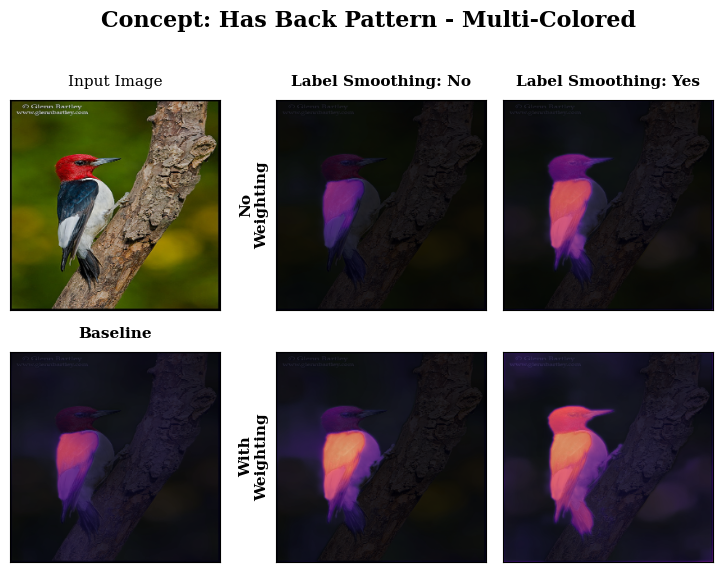

In [202]:
fig = plot_concept_masks_paper_layout(
    predictions_list=[
        baseline_pred,
        no_weight_ls_false,
        no_weight_ls_true,
        weight_ls_false,
        weight_ls_true
    ],
    concept_id=85,
    batch_idx=1,
    concept_names=val_dataset_cub.concepts.to_list(),
    gt_vector=batch_cub.concepts,
    images=batch_cub.images,
    alpha=0.85,
    figsize=(10, 6),
    save=True
)

In [179]:
import numpy as np

np.where(batch_cub.concepts[3].detach().cpu())

(array([  0,   4,   8,  10,  12,  18,  20,  22,  25,  27,  30,  34,  35,
         36,  38,  41,  46,  49,  50,  52,  56,  60,  62,  66,  69,  72,
         76,  78,  85,  87,  89,  92,  95,  99, 105, 110]),)

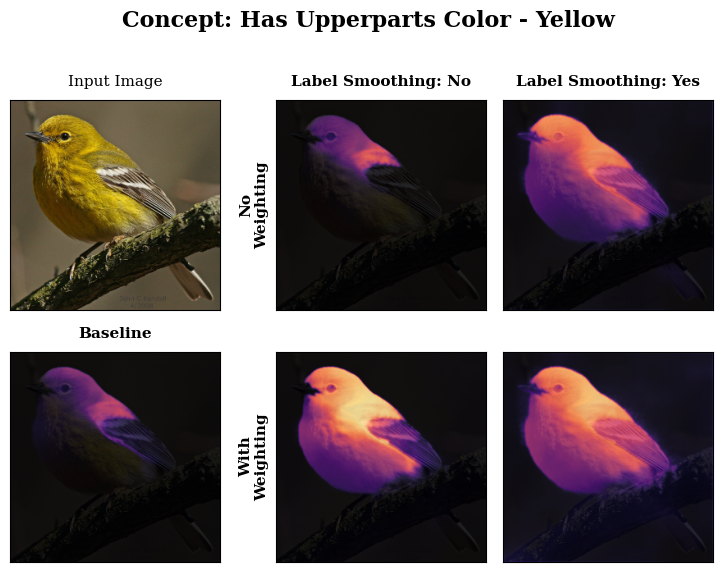

In [198]:
fig = plot_concept_masks_paper_layout(
    predictions_list=[
        baseline_pred,
        no_weight_ls_false,
        no_weight_ls_true,
        weight_ls_false,
        weight_ls_true
    ],
    concept_id=12,
    batch_idx=3,
    concept_names=val_dataset_cub.concepts.to_list(),
    gt_vector=batch_cub.concepts,
    images=batch_cub.images,
    alpha=0.85,
    figsize=(10, 6),
    save=True
)

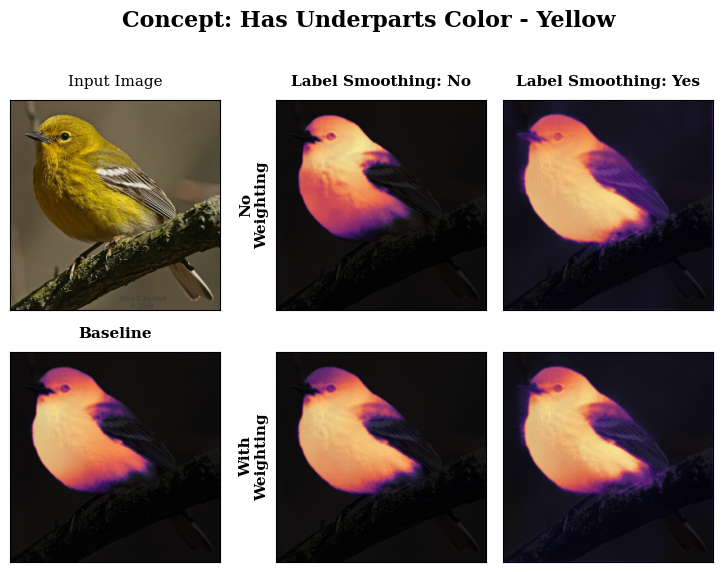

In [199]:
fig = plot_concept_masks_paper_layout(
    predictions_list=[
        baseline_pred,
        no_weight_ls_false,
        no_weight_ls_true,
        weight_ls_false,
        weight_ls_true
    ],
    concept_id=18,
    batch_idx=3,
    concept_names=val_dataset_cub.concepts.to_list(),
    gt_vector=batch_cub.concepts,
    images=batch_cub.images,
    alpha=0.85,
    figsize=(10, 6),
    save=True
)

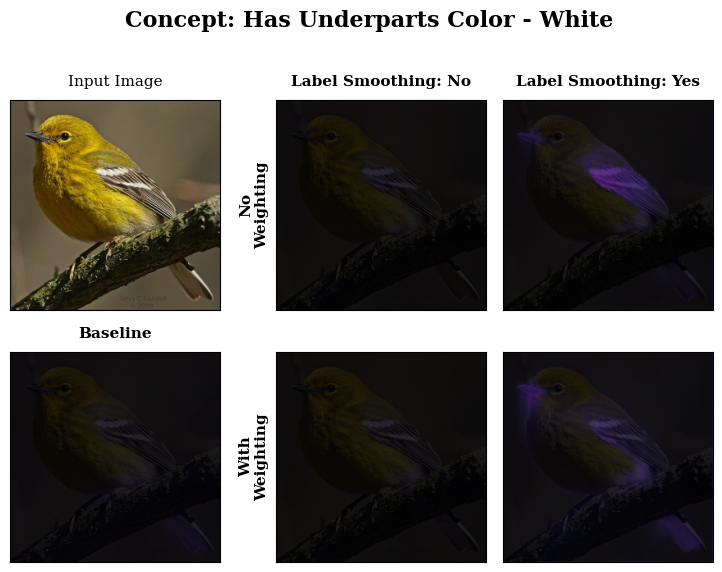

In [200]:
fig = plot_concept_masks_paper_layout(
    predictions_list=[
        baseline_pred,
        no_weight_ls_false,
        no_weight_ls_true,
        weight_ls_false,
        weight_ls_true
    ],
    concept_id=20,
    batch_idx=3,
    concept_names=val_dataset_cub.concepts.to_list(),
    gt_vector=batch_cub.concepts,
    images=batch_cub.images,
    alpha=0.85,
    figsize=(10, 6),
    save=True
)

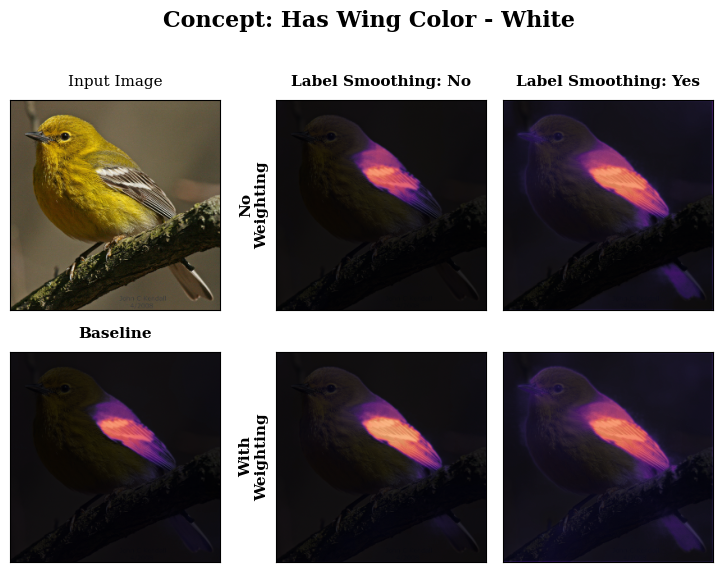

In [201]:
fig = plot_concept_masks_paper_layout(
    predictions_list=[
        baseline_pred,
        no_weight_ls_false,
        no_weight_ls_true,
        weight_ls_false,
        weight_ls_true
    ],
    concept_id=8,
    batch_idx=3,
    concept_names=val_dataset_cub.concepts.to_list(),
    gt_vector=batch_cub.concepts,
    images=batch_cub.images,
    alpha=0.85,
    figsize=(10, 6),
    save=True
)